# **1. Dataset Introduction**

The dataset used in this experiment is the **Telco Customer Churn** dataset. This dataset contains customer information which is used to predict whether a customer will churn or not.

### **Column Descriptions:**
* **customerID**: Unique ID of each customer.
* **gender**: Customer gender (Male, Female).
* **SeniorCitizen**: Whether the customer is a senior citizen (1, 0).
* **Partner**: Whether the customer has a partner (Yes, No).
* **Dependents**: Whether the customer has dependents (Yes, No).
* **tenure**: Number of months the customer has stayed with the company.
* **PhoneService**: Whether the customer has phone service (Yes, No).
* **MultipleLines**: Whether the customer has multiple lines (Yes, No, No phone service).
* **InternetService**: Customer's internet service provider (DSL, Fiber optic, No).
* **OnlineSecurity**: Whether the customer has online security (Yes, No, No internet service).
* **OnlineBackup**: Whether the customer has online backup (Yes, No, No internet service).
* **DeviceProtection**: Whether the customer has device protection (Yes, No, No internet service).
* **TechSupport**: Whether the customer has tech support (Yes, No, No internet service).
* **StreamingTV**: Whether the customer has streaming TV (Yes, No, No internet service).
* **StreamingMovies**: Whether the customer has streaming movies (Yes, No, No internet service).
* **Contract**: The contract term of the customer (Month-to-month, One year, Two year).
* **PaperlessBilling**: Whether the customer has paperless billing (Yes, No).
* **PaymentMethod**: The customer's payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)).
* **MonthlyCharges**: The amount charged to the customer monthly.
* **TotalCharges**: The total amount charged to the customer 
* **Churn**: Whether the customer churned (Yes, No) - **Target Variable**.

# **2. Import Libraries**

In this stage, we import the Python libraries required for data analysis, visualization, and data preprocessing.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import os

# Set visualization theme
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# **3. Loading Dataset**

We load the `customer_churn.csv` dataset from the `customer_churn_raw` directory. Once loaded, we will display the first few rows and a summary of the dataset.

In [17]:
# Load dataset using relative path
dataset_path = '../customer_churn_raw/customer_churn.csv'
df = pd.read_csv(dataset_path)

# Display the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# Display column information and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# **4. Exploratory Data Analysis (EDA)**

In this section, we perform Exploratory Data Analysis (EDA) to understand the characteristics of the dataset, analyze distributions, and identify relationships between features and the target variable `Churn`.

In [19]:
# Descriptive statistics for numerical variables
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


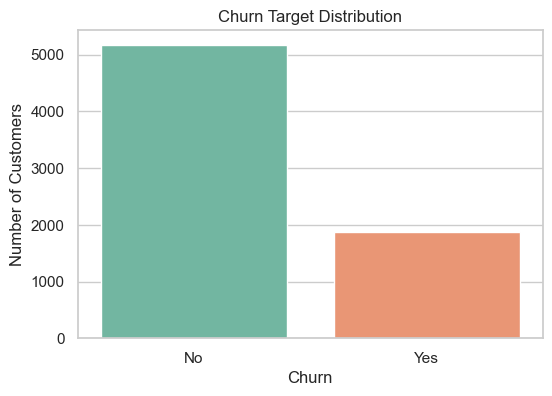

Churn Percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [20]:
# Visualize the distribution of the Churn target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Churn Target Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

# Calculate Churn percentages
print("Churn Percentages:")
print(df['Churn'].value_counts(normalize=True) * 100)

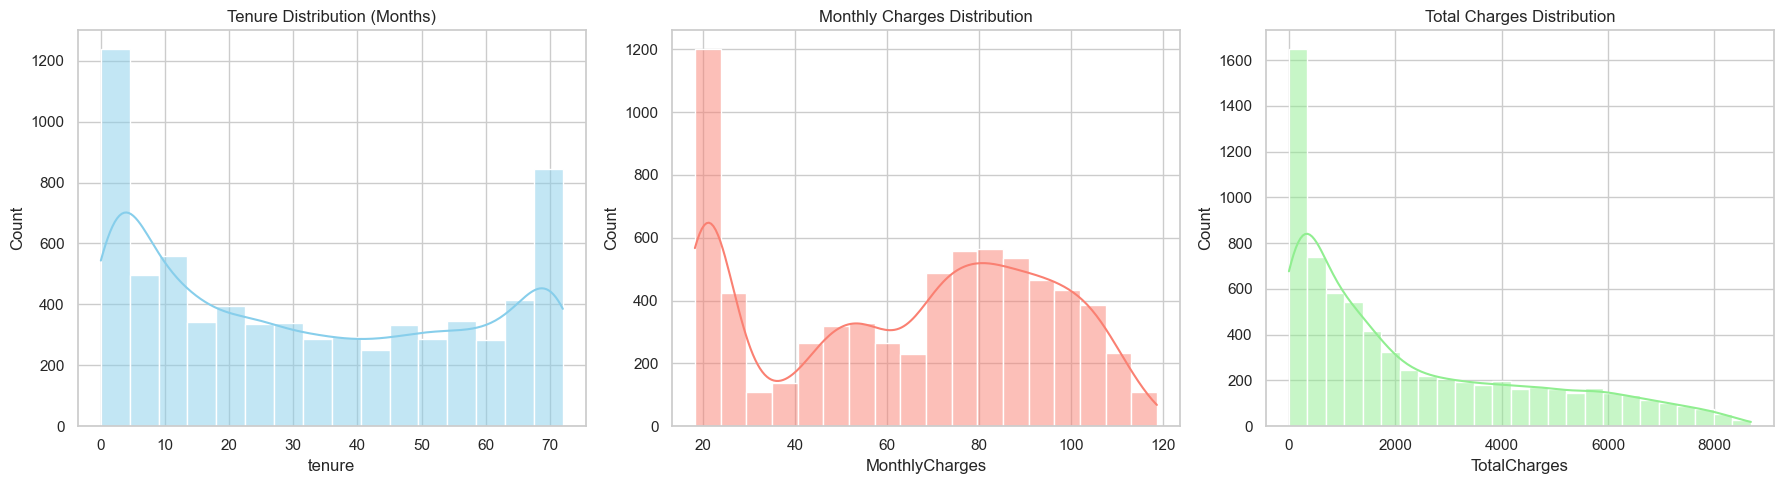

In [ ]:
# Temporarily convert TotalCharges to numeric 
total_charges_temp = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce').fillna(0)

# Visualize distribution of numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['tenure'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Tenure Distribution (Months)')

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Monthly Charges Distribution')

sns.histplot(total_charges_temp, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Total Charges Distribution')

plt.tight_layout()
plt.show()

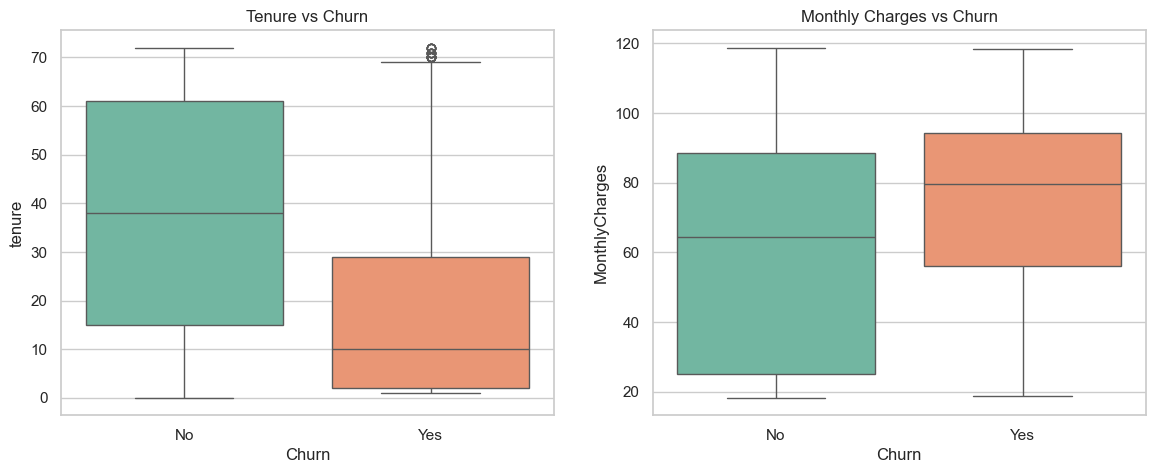

In [22]:
# Relationship between numerical features and Churn using boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2', hue='Churn', legend=False)
axes[0].set_title('Tenure vs Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2', hue='Churn', legend=False)
axes[1].set_title('Monthly Charges vs Churn')

plt.show()

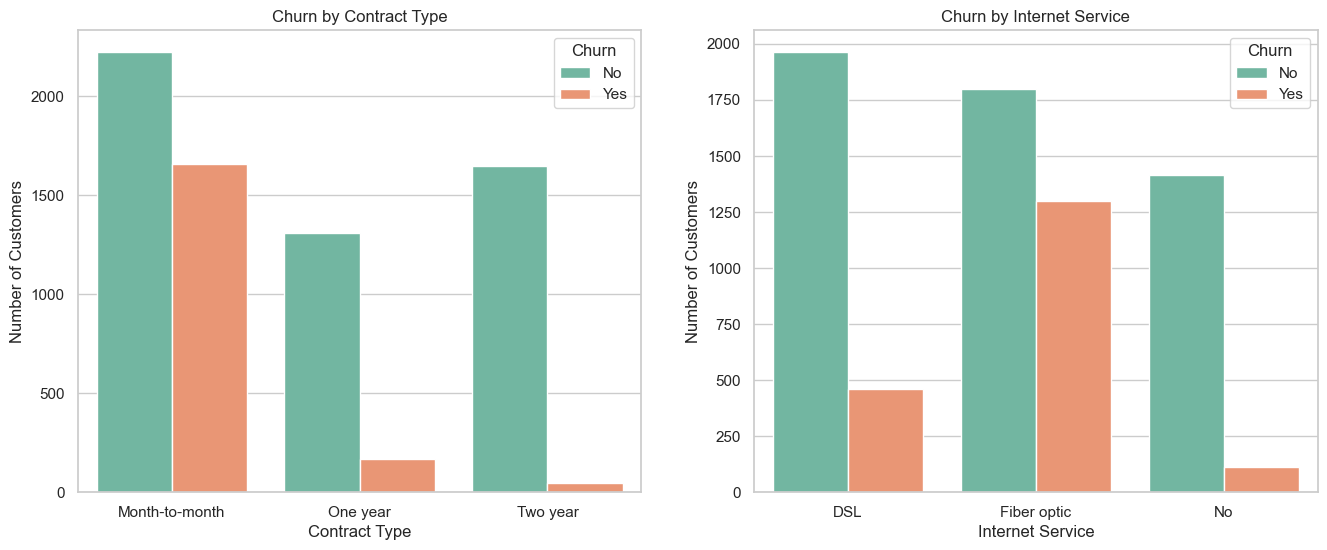

In [23]:
# Analyze Churn based on Contract type and Internet Service
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Contract Type')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Number of Customers')

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1], palette='Set2')
axes[1].set_title('Churn by Internet Service')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Number of Customers')

plt.show()

# **5. Data Preprocessing**

In this section, we perform data preprocessing to clean and prepare the dataset for model training. The steps include:
1. **Data Cleaning**: Dropping `customerID` and handling spaces `' '` in the `TotalCharges` column.
2. **Categorical Encoding**: Using Label Encoding for binary features (2 categories) and One-Hot Encoding for multi-category features.
3. **Dataset Splitting**: Splitting the features (X) and target (y) into Training (80%) and Testing (20%) sets.
4. **Feature Scaling**: Standardizing the numerical columns (`tenure`, `MonthlyCharges`, `TotalCharges`) using `StandardScaler`.
5. **Handling Class Imbalance**: Applying **SMOTE** (Synthetic Minority Over-sampling Technique) strictly on the training set (`X_train`, `y_train`) to balance class representation.

In [24]:
# 1. Drop customerID
df_clean = df.drop(columns=['customerID'])

# 2. Handle missing values in TotalCharges
# Replace empty spaces with NaN
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(' ', np.nan)
# Convert TotalCharges column to float
df_clean['TotalCharges'] = df_clean['TotalCharges'].astype(float)
# Impute missing TotalCharges values with the median
total_charges_median = df_clean['TotalCharges'].median()
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(total_charges_median)

# Check missing values count after cleaning
print("Missing values per column after cleaning:")
print(df_clean.isnull().sum())

Missing values per column after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [25]:
# 3. Categorical Encoding
binary_cols = []
categorical_cols = []
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Identify binary vs multi-category columns
for col in df_clean.drop(columns=['Churn']).columns:
    if col not in numerical_cols:
        if df_clean[col].nunique() == 2:
            binary_cols.append(col)
        else:
            categorical_cols.append(col)

print("Binary columns for Label Encoding:", binary_cols)
print("Multi-category columns for One-Hot Encoding:", categorical_cols)

df_processed = df_clean.copy()

# Label Encode binary columns
le = LabelEncoder()
for col in binary_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

# Label Encode Churn target (Yes=1, No=0)
df_processed['Churn'] = le.fit_transform(df_processed['Churn'])

# One-Hot Encode multi-category columns
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Convert boolean dummy columns to integers
for col in df_processed.columns:
    if df_processed[col].dtype == 'bool':
        df_processed[col] = df_processed[col].astype(int)

df_processed.head()

Binary columns for Label Encoding: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-category columns for One-Hot Encoding: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [27]:
# 4. Feature and Target Separation
X = df_processed.drop(columns=['Churn'])
y = df_processed['Churn']

# 5. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Standardize numerical features using StandardScaler
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print('=== Before SMOTE ===')
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("y_train class distribution:")
print(y_train.value_counts())

# 7. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('\n=== After SMOTE ===')
print(f"X_train_smote shape: {X_train_smote.shape}")
print(f"y_train_smote shape: {y_train_smote.shape}")
print("y_train_smote class distribution:")
print(y_train_smote.value_counts())

print(f"\nX_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


=== Before SMOTE ===
X_train shape: (5634, 30)
y_train shape: (5634,)
y_train class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

=== After SMOTE ===
X_train_smote shape: (8278, 30)
y_train_smote shape: (8278,)
y_train_smote class distribution:
Churn
0    4139
1    4139
Name: count, dtype: int64

X_test shape: (1409, 30)
y_test shape: (1409,)
